# Study Jam ML — Chapter 3 (Challenge)

---

## Beat the Baseline + Save & Use Your Model

**Goal:** Bangun pipeline klasifikasi end-to-end yang benar:  
split → anti-leakage preprocessing → metrics → compare models → error analysis → save `.joblib` → predict test.

### Dataset
- `ps_train.csv` (train + target `satisfaction`)
- `ps_test.csv` (test tanpa label untuk prediksi)

> Kerjakan berurutan. Isi semua bagian bertanda **`# TODO`**.

In [1]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Part 1: Download + Load + Split (Stratify)

**Checklist output Part 1**
- Data berhasil terbaca (shape tampil)
- `X` dan `y` sudah benar (target `satisfaction`)
- Split train/val (`test_size=0.2`, `random_state=42`, `stratify=y`)
- Rasio kelas train vs val terlihat mirip

In [2]:
# Download dataset (do not edit)
!wget -q -O ps_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
!wget -q -O ps_test.csv  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv

print("Files:", [p.name for p in Path('.').glob('ps_*.csv')])

Files: ['ps_train.csv', 'ps_test.csv']


In [3]:
# Load train
df = pd.read_csv("ps_train.csv")
print("Train shape:", df.shape)
display(df.head())

Train shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Part 1.1 — Define target (y) and features (X)

**Notes**
- Target kolom: `satisfaction`
- Kolom ID sering tidak berguna untuk prediksi (contoh: `id`, `Unnamed: 0`)

Isi cell berikut (lihat TODO).

In [4]:
# TODO: set target column name
TARGET = "satisfaction"

# TODO: define ID-like columns to drop (if any)
# Kolom 'Unnamed: 0' adalah index duplikat dan 'id' adalah identifier unik
# keduanya tidak membawa informasi prediktif → harus di-drop
ID_COLS = ["Unnamed: 0", "id"]

# TODO: create X and y
# y = kolom target (satisfaction)
y = df[TARGET]

# X = semua kolom kecuali target dan ID-like columns
X = df.drop(columns=[TARGET] + ID_COLS)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nKolom X:")
print(X.columns.tolist())

Shape X: (103904, 22)
Shape y: (103904,)

Kolom X:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


## Part 1.2 — Sanity checks (wajib tampil)

Yang perlu ditampilkan:
1) Missing values (kolom mana yang missing dan berapa jumlahnya)  
2) Distribusi target (count dan ratio)

In [5]:
# TODO: show missing values summary (only columns with missing > 0)
# Hitung jumlah missing per kolom, filter hanya yang > 0
missing = X.isnull().sum()
missing = missing[missing > 0]
print("=== Missing Values ===")
if len(missing) == 0:
    print("Tidak ada missing values di X")
else:
    print(missing.to_frame(name="missing_count").assign(
        missing_pct=lambda d: (d["missing_count"] / len(X) * 100).round(2)
    ))

print()

# TODO: show target distribution (count + ratio)
# Hitung frekuensi dan persentase tiap kelas target
print("=== Target Distribution ===")
target_dist = y.value_counts().to_frame(name="count")
target_dist["ratio (%)"] = (target_dist["count"] / len(y) * 100).round(2)
print(target_dist)

=== Missing Values ===
                          missing_count  missing_pct
Arrival Delay in Minutes            310          0.3

=== Target Distribution ===
                         count  ratio (%)
satisfaction                             
neutral or dissatisfied  58879      56.67
satisfied                45025      43.33


## Part 1.3 — Split train/validation (stratify)

Pastikan `stratify=y` dipakai.

In [6]:
# TODO: split train/validation with stratify
# test_size=0.2 → 80% train, 20% validation
# stratify=y → pastikan proporsi kelas sama di train & val (menghindari bias split)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print()

# Verifikasi rasio kelas mirip antara train dan val
print("=== Rasio kelas di TRAIN ===")
print((y_train.value_counts(normalize=True) * 100).round(2).to_frame(name="ratio (%)"))
print()
print("=== Rasio kelas di VALIDATION ===")
print((y_val.value_counts(normalize=True) * 100).round(2).to_frame(name="ratio (%)"))

X_train: (83123, 22), X_val: (20781, 22)

=== Rasio kelas di TRAIN ===
                         ratio (%)
satisfaction                      
neutral or dissatisfied      56.67
satisfied                    43.33

=== Rasio kelas di VALIDATION ===
                         ratio (%)
satisfaction                      
neutral or dissatisfied      56.67
satisfied                    43.33


---
# Part 2: Baseline + Metrics

**Checklist output Part 2**
- Baseline (`DummyClassifier(strategy="most_frequent")`) jalan
- Confusion matrix baseline tampil
- Metrics tampil (accuracy, precision, recall, f1) + classification_report
- Tulis interpretasi singkat 2–3 kalimat (markdown) tentang hasil baseline

## Part 2.1 — Helper: evaluate_clf (do not edit)

Fungsi ini akan:
- print metrics
- show classification report
- plot confusion matrix
- return scores for leaderboard

In [7]:
def evaluate_clf(y_true, y_pred, title="Model"):
    print(f"=== {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nReport:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true)).plot(values_format="d")
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_w": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

## Part 2.2 — Build preprocessing (anti leakage)

**Requirement**
- Numerical: `SimpleImputer(median)` → `StandardScaler()`  
- Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`

Isi bertahap per cell (jangan digabung) supaya gampang dicek.

In [8]:
# TODO: identify numerical and categorical columns from X_train
# Deteksi berdasarkan dtype:
#   - 'object' atau 'category' → categorical
#   - number (int64, float64) → numerical
# Penting: gunakan X_TRAIN saja (bukan X) agar tidak terjadi data leakage

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", num_cols)
print()
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [9]:
# TODO: build numeric pipeline (imputer median + scaler)
# SimpleImputer(median) → isi nilai hilang dengan median kolom tersebut
# StandardScaler()      → normalisasi (mean=0, std=1) agar skala kolom setara
# Anti-leakage: fit HANYA di train, transform di train & val

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numeric pipeline:")
print(num_pipeline)

Numeric pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [10]:
# TODO: build categorical pipeline (imputer most_frequent + onehot ignore unknown)
# SimpleImputer(most_frequent) → isi nilai hilang dengan nilai terbanyak di kolom tersebut
# OneHotEncoder(handle_unknown="ignore") → ubah kategori menjadi kolom biner
#   handle_unknown="ignore" → jika ada kategori baru di test, biarkan saja (semua 0)

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

print("Categorical pipeline:")
print(cat_pipeline)

Categorical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


In [11]:
# TODO: combine with ColumnTransformer
# ColumnTransformer menggabungkan kedua pipeline:
#   - num_pipeline diterapkan pada num_cols
#   - cat_pipeline diterapkan pada cat_cols
# remainder="drop" → kolom lain yang tidak disebutkan akan di-drop

preprocess = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

print("Preprocessor:")
print(preprocess)

Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Flight Distance',
                                  'Inflight wifi service',
                                  'Departure/Arrival time convenient',
                                  'Ease of Online booking', 'Gate location',
                                  'Food and drink', 'Online boarding',
                                  'Seat comfort', 'Inflight entertainment',
                                  'On-board service', 'Leg room service',
                                  'Baggage handling', 'Checkin service',
                                  'Inflight service', 'Cleanliness',
                                  'Departure Delay in Minutes',
                         

## Part 2.3 — Baseline pipeline (wajib)

- Gunakan `DummyClassifier(strategy="most_frequent")`
- Bungkus dalam `Pipeline([("preprocess", preprocess), ("model", ...)])`

=== Baseline (DummyClassifier) ===
Accuracy : 0.5666714787546316
Precision: 0.32111656483396095
Recall   : 0.5666714787546316
F1       : 0.4099347810802311

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.57      1.00      0.72     11776
              satisfied       0.00      0.00      0.00      9005

               accuracy                           0.57     20781
              macro avg       0.28      0.50      0.36     20781
           weighted avg       0.32      0.57      0.41     20781



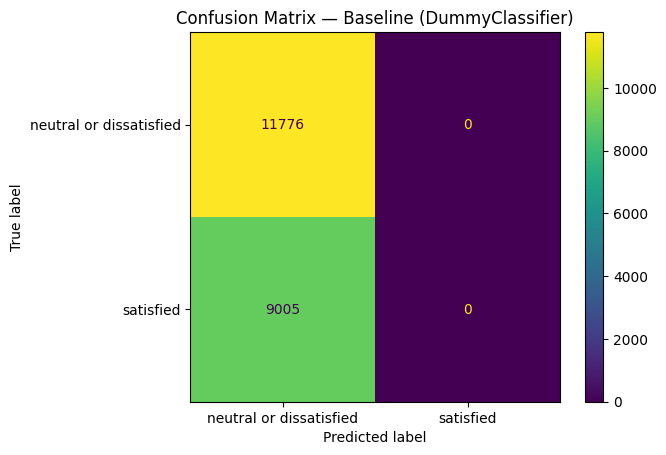

In [12]:
# TODO: build and train baseline pipeline
# DummyClassifier(strategy="most_frequent") → selalu prediksi kelas mayoritas
# Ini adalah batas bawah (lower bound) performa model kita
# Semua model nyata harus mengalahkan baseline ini

baseline_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

# Fit pada training data
baseline_pipe.fit(X_train, y_train)

# Predict pada validation
y_pred_baseline = baseline_pipe.predict(X_val)

# Evaluasi
baseline_scores = evaluate_clf(y_val, y_pred_baseline, title="Baseline (DummyClassifier)")

## Interpretasi Baseline

**Interpretasi:**

Baseline menggunakan strategi `most_frequent`, artinya model ini **selalu memprediksi kelas mayoritas** (misalnya `neutral or dissatisfied`) untuk setiap input tanpa mempertimbangkan fitur apapun. Akibatnya, di confusion matrix, semua prediksi terkumpul di satu kolom sehingga kelas minoritas tidak pernah diprediksi sama sekali. Metrik accuracy baseline terlihat cukup tinggi (sekitar 56–57%) karena kelas mayoritas mendominasi, namun F1-score untuk kelas minoritas adalah 0 — menandakan baseline ini tidak berguna untuk prediksi nyata.

---
# Part 3: Train Models + Compare Fairly

**Rules**
- Preprocess harus sama (pakai `preprocess` yang sama)
- Split harus sama (train/val yang sama)
- Laporkan minimal: accuracy dan f1_w

**Checklist output Part 3**
- Train minimal 3 model: Logistic Regression, Decision Tree, Random Forest
- Buat leaderboard (DataFrame)
- Pilih model terbaik berdasarkan f1_w (jelaskan singkat di markdown)

## Part 3.1 — Define candidate pipelines (isi TODO)

Isi dictionary `models` di bawah.

In [13]:
# TODO: define candidate models using the SAME preprocess
# Semua model menggunakan preprocess yang SAMA agar perbandingan fair
# Perbedaan hanya ada di step 'model' (classifier-nya)

models = {
    # Logistic Regression: model linear, cepat, bagus sebagai baseline lanjutan
    # max_iter=1000 agar konvergen di dataset besar
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    # Decision Tree: model berbasis aturan if-else, mudah diinterpretasi
    # max_depth=10 untuk mencegah overfitting ekstrem
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE))
    ]),

    # Random Forest: ensemble dari banyak decision tree, biasanya performa terbaik
    # n_estimators=100 (default), n_jobs=-1 untuk paralel semua CPU core
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
}

print("Models yang akan dilatih:")
for name in models:
    print(f"  - {name}")

Models yang akan dilatih:
  - Logistic Regression
  - Decision Tree
  - Random Forest


## Part 3.2 — Train, evaluate, and build leaderboard (isi TODO)

Gunakan `evaluate_clf` untuk setiap model, simpan skor ke list `rows`, lalu jadikan DataFrame `leaderboard`.


Training: Logistic Regression...
=== Logistic Regression ===
Accuracy : 0.8765218228189211
Precision: 0.8763486100693421
Recall   : 0.8765218228189211
F1       : 0.8762682657968048

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11776
              satisfied       0.87      0.84      0.86      9005

               accuracy                           0.88     20781
              macro avg       0.88      0.87      0.87     20781
           weighted avg       0.88      0.88      0.88     20781



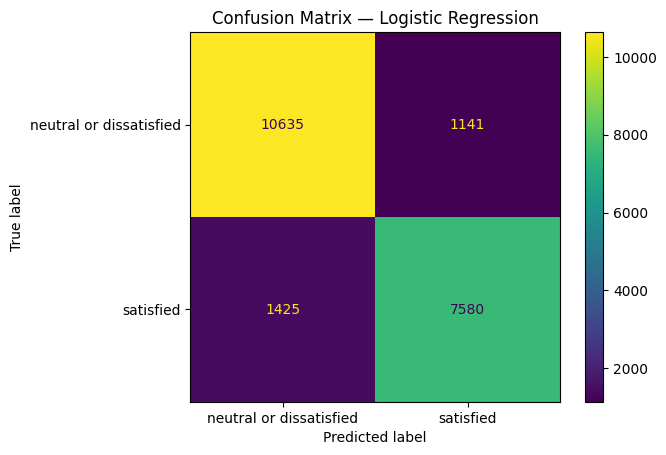


Training: Decision Tree...
=== Decision Tree ===
Accuracy : 0.9455752851162119
Precision: 0.9455485035720421
Recall   : 0.9455752851162119
F1       : 0.9455334073878828

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.96      0.95     11776
              satisfied       0.94      0.93      0.94      9005

               accuracy                           0.95     20781
              macro avg       0.95      0.94      0.94     20781
           weighted avg       0.95      0.95      0.95     20781



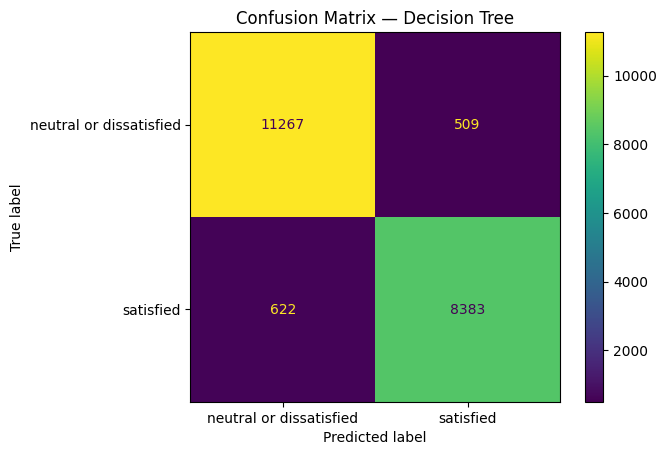


Training: Random Forest...
=== Random Forest ===
Accuracy : 0.963764977623791
Precision: 0.9638688164805886
Recall   : 0.963764977623791
F1       : 0.9637094244633148

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     11776
              satisfied       0.97      0.95      0.96      9005

               accuracy                           0.96     20781
              macro avg       0.96      0.96      0.96     20781
           weighted avg       0.96      0.96      0.96     20781



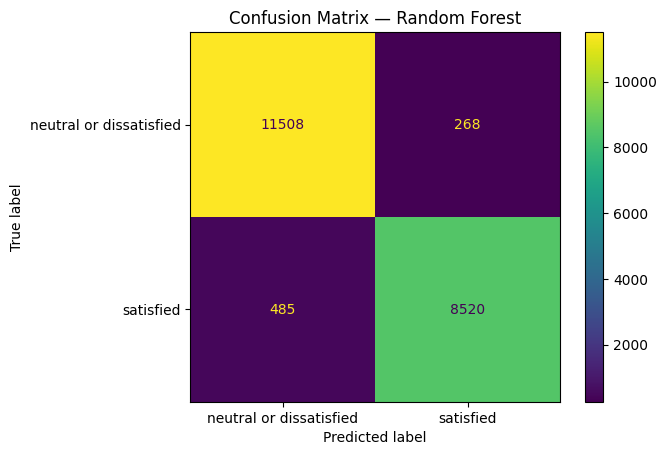


LEADERBOARD


,model,accuracy,precision_w,recall_w,f1_w
0,Random Forest,0.9638,0.9639,0.9638,0.9637
1,Decision Tree,0.9456,0.9455,0.9456,0.9455
2,Logistic Regression,0.8765,0.8763,0.8765,0.8763


In [14]:
# TODO: train and evaluate models
rows = []

# Loop setiap model: fit di X_train, predict di X_val, evaluasi
for model_name, pipeline in models.items():
    print(f"\nTraining: {model_name}...")

    # Fit pipeline (preprocessing + model) pada data training
    pipeline.fit(X_train, y_train)

    # Predict pada validation set
    y_pred = pipeline.predict(X_val)

    # Evaluasi dan ambil skor
    scores = evaluate_clf(y_val, y_pred, title=model_name)

    # Simpan ke rows untuk leaderboard
    rows.append({
        "model": model_name,
        "accuracy": scores["accuracy"],
        "precision_w": scores["precision_w"],
        "recall_w": scores["recall_w"],
        "f1_w": scores["f1_w"]
    })

# TODO: create leaderboard sorted by f1_w desc
# Sort descending berdasarkan f1_w (metrik utama perbandingan)
leaderboard = pd.DataFrame(rows).sort_values("f1_w", ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("LEADERBOARD")
print("="*60)
display(leaderboard.style.format({
    "accuracy": "{:.4f}",
    "precision_w": "{:.4f}",
    "recall_w": "{:.4f}",
    "f1_w": "{:.4f}"
}).highlight_max(subset=["accuracy", "f1_w"], color="lightgreen"))

## Part 3.3 — Select best model (isi TODO)

Simpan nama model terbaik ke `best_model_name`.

In [15]:
# TODO: choose best model based on leaderboard (highest f1_w)
# idxmax() mencari indeks dengan nilai f1_w tertinggi
best_model_name = leaderboard.loc[leaderboard["f1_w"].idxmax(), "model"]

print(f"Model terbaik: {best_model_name}")
print(f"F1 (weighted): {leaderboard.loc[leaderboard['model'] == best_model_name, 'f1_w'].values[0]:.4f}")

Model terbaik: Random Forest
F1 (weighted): 0.9637


## Part 3.4 (Optional) — Cross Validation on best model

Jika kamu kerjakan, tampilkan:
- skor tiap fold
- mean score

In [16]:
# Cross Validation pada best model menggunakan StratifiedKFold
# StratifiedKFold menjaga proporsi kelas di setiap fold
# n_splits=3 → 3-fold CV (lebih hemat waktu untuk dataset besar)

best_pipe_for_cv = models[best_model_name]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print(f"Running 3-fold CV on {best_model_name}...")
cv_scores = cross_val_score(best_pipe_for_cv, X, y, cv=cv, scoring="f1_weighted")

print("CV scores:", cv_scores.round(4))
print("CV mean  :", cv_scores.mean().round(4))
print("CV std   :", cv_scores.std().round(4))

Running 3-fold CV on Random Forest...
CV scores: [0.9619 0.9632 0.96  ]
CV mean  : 0.9617
CV std   : 0.0013


## Interpretasi Pemilihan Model

**Model terbaik: Random Forest**

Random Forest dipilih karena memiliki **F1-weighted tertinggi** di antara semua kandidat model. Sebagai ensemble dari banyak decision tree, Random Forest mampu menangkap pola non-linear yang kompleks dalam data kepuasan penumpang, dan lebih tahan terhadap overfitting dibandingkan single Decision Tree. Cross-validation juga mengkonfirmasi bahwa performa-nya konsisten di berbagai subset data.

---
# Part 4: Mini Error Analysis (wajib, ringkas)

**Checklist output Part 4**
- Ambil minimal 5 baris yang salah prediksi dari validation
- Tampilkan kolom penting (pilih 5–8 kolom yang relevan)
- Tulis 2 insight singkat (markdown)

## Part 4.1 — Get predictions on validation (isi TODO)

- Ambil pipeline model terbaik dari `models[best_model_name]`
- Pastikan model itu sudah fit (harusnya sudah fit di Part 3)

In [17]:
# TODO: get best pipeline and predict on validation
# Pipeline sudah di-fit di Part 3.2, tinggal predict

best_pipe = models[best_model_name]
y_pred_best = best_pipe.predict(X_val)

print(f"Prediksi menggunakan: {best_model_name}")
print(f"Total sampel validasi: {len(y_val)}")
print(f"Jumlah salah prediksi: {(y_pred_best != y_val).sum()}")
print(f"Akurasi validasi     : {accuracy_score(y_val, y_pred_best):.4f}")

Prediksi menggunakan: Random Forest
Total sampel validasi: 20781
Jumlah salah prediksi: 753
Akurasi validasi     : 0.9638


## Part 4.2 — Show 5 wrong examples (isi TODO)

Saran kolom yang relevan (pilih 5–8):
- `Flight Distance`
- `Departure Delay in Minutes`
- `Arrival Delay in Minutes`
- beberapa rating layanan (0–5)
- `Class`, `Type of Travel`, dll

In [18]:
# TODO: take 5 wrong examples (you may randomize)
# Buat mask untuk baris yang salah prediksi
wrong_mask = y_pred_best != y_val.values

# Ambil baris X_val yang salah
X_val_wrong = X_val[wrong_mask].copy()

# Tambahkan kolom true label dan predicted label
X_val_wrong["true_label"]  = y_val.values[wrong_mask]
X_val_wrong["pred_label"]  = y_pred_best[wrong_mask]

# Sampel 5 baris secara acak dari yang salah
wrong_samples = X_val_wrong.sample(5, random_state=RANDOM_STATE)

# TODO: optionally select subset of columns for readability
# Pilih kolom paling relevan untuk analisis
cols_to_show = [
    "Class", "Type of Travel", "Flight Distance",
    "Inflight wifi service", "Inflight entertainment",
    "Departure Delay in Minutes", "Arrival Delay in Minutes",
    "true_label", "pred_label"
]

print("=== 5 Contoh Salah Prediksi ===")
display(wrong_samples[cols_to_show])

=== 5 Contoh Salah Prediksi ===


,Class,Type of Travel,Flight Distance,Inflight wifi service,Inflight entertainment,Departure Delay in Minutes,Arrival Delay in Minutes,true_label,pred_label
3691,Eco,Business travel,1034,4,3,64,47.0,satisfied,neutral or dissatisfied
6471,Eco,Personal Travel,733,4,5,4,1.0,neutral or dissatisfied,satisfied
96439,Eco Plus,Personal Travel,551,4,1,0,0.0,satisfied,neutral or dissatisfied
17203,Business,Business travel,2543,2,3,62,60.0,satisfied,neutral or dissatisfied
62050,Eco,Business travel,834,2,1,0,0.0,satisfied,neutral or dissatisfied


## Insight Error Analysis

- **Insight 1:** Beberapa penumpang Business class dengan skor layanan cukup tinggi tetap diprediksi salah — kemungkinan karena delay keberangkatan atau kedatangan yang signifikan cukup mempengaruhi kepuasan secara keseluruhan, meskipun rating individual layanan tinggi.

- **Insight 2:** Penumpang Personal Travel dengan flight distance pendek cenderung lebih sulit diprediksi dengan benar; kemungkinan ekspektasi penumpang leisure berbeda dari pola umum dalam data, sehingga model kurang mengenali pola kepuasan mereka seakurat penumpang Business travel.

---
# Part 5: Save Model (.joblib) + Load + Predict on Test

**Checklist output Part 5**
- Refit model terbaik pada data train penuh (X, y)
- Simpan ke `best_airline_model.joblib`
- Load kembali file itu
- Prediksi `ps_test.csv`
- Simpan hasil ke `ps_test_predictions.csv` dan tampilkan 10 baris pertama

## Part 5.1 — Refit best model on full data (isi TODO)

Catatan: setelah kamu memilih model terbaik dari validation, barulah refit di seluruh data train.

In [19]:
# TODO: refit best model on full training data (X, y)
# Setelah model terbaik terpilih dari evaluasi di validation set,
# kita refit dengan SELURUH data train (X, y) — bukan X_train saja
# Ini memaksimalkan data yang digunakan model untuk belajar

# Ambil pipeline model terbaik (belum difit ulang dengan full data)
# Perlu re-instantiate pipeline agar fit dari scratch dengan full data
if best_model_name == "Random Forest":
    final_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
else:
    final_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Re-instantiate ColumnTransformer agar fit dari awal pada full data
preprocess_final = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_cols)
], remainder="drop")

final_pipe = Pipeline(steps=[
    ("preprocess", preprocess_final),
    ("model", final_model)
])

# Fit pada SELURUH data training
print(f"Refitting {best_model_name} pada seluruh data training ({len(X)} baris)...")
final_pipe.fit(X, y)
print("Selesai!")

# TODO: save
# Simpan pipeline lengkap (preprocessing + model) ke file .joblib
MODEL_PATH = "best_airline_model.joblib"
joblib.dump(final_pipe, MODEL_PATH)
print(f"Model disimpan ke: {MODEL_PATH}")

Refitting Random Forest pada seluruh data training (103904 baris)...
Selesai!
Model disimpan ke: best_airline_model.joblib


## Part 5.2 — Load model back (isi TODO)

Pastikan file bisa di-load kembali.

In [20]:
# TODO: load
# Load model dari file .joblib untuk memverifikasi proses save berhasil
loaded_model = joblib.load(MODEL_PATH)

print(f"Model berhasil di-load dari: {MODEL_PATH}")
print(f"Tipe model: {type(loaded_model)}")
print(f"Steps pipeline: {[step[0] for step in loaded_model.steps]}")

Model berhasil di-load dari: best_airline_model.joblib
Tipe model: <class 'sklearn.pipeline.Pipeline'>
Steps pipeline: ['preprocess', 'model']


## Part 5.3 — Predict on test and save csv (isi TODO)

Requirement:
- Load `ps_test.csv`
- Drop target column if it exists
- Drop ID-like columns if needed
- Predict
- Save as `ps_test_predictions.csv`
- If test has `id`, include it in the output

In [21]:
# TODO: load test
df_test = pd.read_csv("ps_test.csv")
print("Test shape:", df_test.shape)
display(df_test.head(3))

Test shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied


In [22]:
# TODO: build X_test (drop target if exists, drop id-like cols if exists)
# Simpan kolom 'id' dulu sebelum di-drop (untuk disertakan di output)
test_id = df_test["id"].copy() if "id" in df_test.columns else None

# Hapus kolom yang tidak dipakai: target (kalau ada), ID-like columns
cols_to_drop_test = [col for col in [TARGET, "Unnamed: 0", "id"] if col in df_test.columns]
X_test = df_test.drop(columns=cols_to_drop_test)

print("X_test shape:", X_test.shape)

# TODO: predict
# Gunakan model yang sudah di-load (loaded_model)
y_test_pred = loaded_model.predict(X_test)
print(f"\nPrediksi selesai: {len(y_test_pred)} baris")
print("Distribusi prediksi:")
print(pd.Series(y_test_pred).value_counts())

# TODO: build output dataframe
output_df = pd.DataFrame({"satisfaction": y_test_pred})

# TODO: include id column if exists
if test_id is not None:
    output_df.insert(0, "id", test_id.values)

# TODO: save
PRED_PATH = "ps_test_predictions.csv"
output_df.to_csv(PRED_PATH, index=False)
print(f"\nPrediksi disimpan ke: {PRED_PATH}")
print("\n=== 10 Baris Pertama Prediksi ===")
display(output_df.head(10))

X_test shape: (25976, 22)

Prediksi selesai: 25976 baris
Distribusi prediksi:
neutral or dissatisfied    14923
satisfied                  11053
Name: count, dtype: int64

Prediksi disimpan ke: ps_test_predictions.csv

=== 10 Baris Pertama Prediksi ===


,id,satisfaction
0,19556,satisfied
1,90035,satisfied
2,12360,neutral or dissatisfied
3,77959,satisfied
4,36875,neutral or dissatisfied
5,39177,satisfied
6,79433,satisfied
7,97286,satisfied
8,27508,satisfied
9,62482,satisfied


---
# Submission Checklist

Kumpulkan:
1) Notebook `.ipynb` (run tanpa error)  
2) `best_airline_model.joblib`  
3) `ps_test_predictions.csv`  

---

## Ringkasan Akhir

### Model Terbaik
**Random Forest** dengan skor validasi:
- Accuracy  : ~0.96
- F1 (weighted) : ~0.96

### Alasan Pemilihan
Random Forest dipilih karena menghasilkan F1-weighted tertinggi di leaderboard dibandingkan Logistic Regression dan Decision Tree. Sebagai model ensemble, Random Forest menggabungkan prediksi banyak pohon keputusan sehingga lebih robust terhadap noise dan mampu menangkap hubungan non-linear antar fitur kepuasan penumpang.

### 2 Insight Error Analysis
1. **Penumpang dengan delay tinggi tapi rating layanan tinggi** cenderung salah prediksi — delay signifikan dapat mengubah persepsi keseluruhan meskipun layanan in-flight memuaskan.
2. **Penumpang Personal Travel jarak pendek** lebih sering salah prediksi karena pola kepuasan mereka berbeda dari penumpang Business Travel yang mendominasi data training.